In [1]:
!pip install efficientnet_pytorch timm
!pip install -U albumentations

  Preparing metadata (setup.py) ... done
  Created wheel for efficientnet_pytorch: filename=efficientnet_pytorch-0.7.1-py3-none-any.whl size=16424 sha256=a15e955154023c808c07b4687714611a437e2fbac68b680e539b681cb0c7e34a
  Stored in directory: /root/.cache/pip/wheels/03/3f/e9/911b1bc46869644912bda90a56bcf7b960f20b5187feea3baf
Successfully built efficientnet_pytorch
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.7/41.7 kB 1.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.0/66.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 290.6/290.6 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 632.7/632.7 kB 14.5 MB/s eta 0:00:00
  Attempting uninstall: albucore
    Found existing installation: albucore 0.0.19
    Uninstalling albucore-0.0.19:
      Successfully uninstalled albucore-0.0.19
  Attempting uninstall: albumentations
    Found existing installation: albumentations 1.4.20
    Uninstalling albumentations-1.4.20:
      Successful

In [2]:
import os
import cv2
import shutil
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tqdm.notebook import tqdm
from collections import Counter
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.utils import Sequence
from tensorflow.keras import mixed_precision
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import mixed_precision
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import EfficientNetB0
from sklearn.utils.class_weight import compute_class_weight
import albumentations as A
from albumentations import GaussNoise, RandomBrightnessContrast, CoarseDropout
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dropout, Dense, BatchNormalization, Activation

In [3]:
# Set parameters
IMG_SIZE = (224, 224)  
BATCH_SIZE = 32
DATASET_PATH = "/kaggle/input/crack-this-ass/processed_data"
crack_img_dir = '/kaggle/input/crack-this-ass/processed_data/crack/images'
no_crack_img_dir = '/kaggle/input/crack-this-ass/processed_data/no_crack'

In [4]:
crack = [(f, 1) for f in os.listdir(crack_img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
no_crack = [(f, 0) for f in os.listdir(no_crack_img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
all_images = crack + no_crack

In [5]:
print(f"Crack images count: {len(crack)}")
print(f"No crack images count: {len(no_crack)}")
print(f"Total images in all_images: {len(all_images)}")

Crack images count: 789
No crack images count: 1086
Total images in all_images: 1875


In [6]:
df = pd.DataFrame(all_images, columns=['filename', 'label'])
valid_rows = []
for i, row in df.iterrows():
    fname = row['filename']
    label = row['label']
    path = os.path.join(crack_img_dir if label == 1 else no_crack_img_dir, fname)
    try:
        img = load_img(path, target_size=IMG_SIZE)
        _ = img_to_array(img)
        valid_rows.append(True)
    except Exception as e:
        print(f"Skipping {fname}: {e}")
        valid_rows.append(False)
df = df[valid_rows].reset_index(drop=True)
df['label'] = df['label'].astype(str).str.strip().astype(int)

In [7]:
# Split train vs temp (val + test)
train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)
# Split val vs test (from temp)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

In [8]:
print("Train class counts:\n", train_df['label'].value_counts())
print("Val class counts:\n", val_df['label'].value_counts())
print("Test class counts:\n", test_df['label'].value_counts())

Train class counts:
 label
0    869
1    631
Name: count, dtype: int64
Val class counts:
 label
0    108
1     79
Name: count, dtype: int64
Test class counts:
 label
0    109
1     79
Name: count, dtype: int64


In [9]:
train_df.to_csv('train.csv', index=False)
val_df.to_csv('val.csv', index=False)
test_df.to_csv('test.csv', index=False)

In [10]:
train_img_dir = '/kaggle/working/Train'
val_img_dir = '/kaggle/working/Val'
test_img_dir = '/kaggle/working/Test'
os.makedirs(train_img_dir, exist_ok=True)
os.makedirs(val_img_dir, exist_ok=True)
os.makedirs(test_img_dir, exist_ok=True)

In [11]:
def moving_img(df, crack_img_dir, no_crack_img_dir, destination_dir):
    for _, row in df.iterrows():
        fname = row['filename']
        label = row['label']
        src_path = os.path.join(crack_img_dir if label == 1 else no_crack_img_dir, fname)
        dst_path = os.path.join(destination_dir, fname)
        if os.path.exists(src_path):
            shutil.copy(src_path, dst_path)
        else:
            print(f"Missing image: {src_path}")

In [12]:
moving_img(train_df, crack_img_dir, no_crack_img_dir, train_img_dir)
moving_img(val_df, crack_img_dir, no_crack_img_dir, val_img_dir)
moving_img(test_df, crack_img_dir, no_crack_img_dir, test_img_dir)

In [13]:
class CrackDataGenerator(Sequence):
    def __init__(self, dataframe, directory, x_col, y_col, target_size, 
                 batch_size=32, class_mode='binary', shuffle=True, 
                 preprocessing_function=None, augment=False, 
                 workers=1, use_multiprocessing=False, max_queue_size=10, 
                 seed=42, **kwargs):
        super().__init__(**kwargs)
        self.dataframe = dataframe.reset_index(drop=True)
        self.directory = directory
        self.x_col = x_col
        self.y_col = y_col
        self.target_size = target_size
        self.batch_size = batch_size
        self.class_mode = class_mode
        self.shuffle = shuffle
        self.preprocessing_function = preprocessing_function
        self.augment = augment
        self.seed = seed
        self.use_multiprocessing = use_multiprocessing
        self.workers = workers
        self.max_queue_size = max_queue_size
        if self.augment:
            self.aug = A.Compose([
                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.2),
                RandomBrightnessContrast(p=0.5),
                GaussNoise(p=0.2),
                A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=0.5),
                A.OneOf([
                    A.Blur(blur_limit=3),
                    A.MedianBlur(blur_limit=3),
                    A.MotionBlur(blur_limit=3)
                ], p=0.2),
                CoarseDropout(
                    max_holes=8, max_height=16, max_width=16,
                    min_holes=2, min_height=8, min_width=8,
                    fill_value=0, mask_fill_value=None, p=0.3
                ),
                A.Resize(*self.target_size),
            ])
        else:
            self.aug = A.Resize(*self.target_size)
        self.indexes = np.arange(len(self.dataframe))
        self.on_epoch_end()
    def __len__(self):
        return int(np.ceil(len(self.dataframe) / self.batch_size))
    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_df = self.dataframe.iloc[batch_indexes]
        batch_x = np.empty((len(batch_df), *self.target_size, 3), dtype=np.float32)
        batch_y = np.empty(len(batch_df), dtype=np.float32)
        for i, (_, row) in enumerate(batch_df.iterrows()):
            img_path = os.path.join(self.directory, row[self.x_col])
            try:
                img = cv2.imread(img_path)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                if self.augment:
                    augmented = self.aug(image=img)
                else:
                    augmented = self.aug(image=img)
                x = augmented['image'].astype(np.float32)
                if self.preprocessing_function:
                    x = self.preprocessing_function(x)
                batch_x[i] = x
                batch_y[i] = np.clip(float(row[self.y_col]), 0, 1)
            except Exception as e:
                print(f"Error loading image {img_path}: {e}")
                continue
        return batch_x, batch_y
    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)

In [14]:
# Build Generators
train_generator = CrackDataGenerator(
    dataframe=train_df,
    directory=train_img_dir,
    x_col='filename',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True,
    preprocessing_function=preprocess_input,
    augment=True, 
    workers=4,
    use_multiprocessing=True,
    max_queue_size=10
)

val_generator = CrackDataGenerator(
    dataframe=val_df,
    directory=val_img_dir,
    x_col='filename',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False,  
    preprocessing_function=preprocess_input,  
    augment=False,   
    workers=2,
    use_multiprocessing=True,
    max_queue_size=10
)

test_generator = CrackDataGenerator(
    dataframe=test_df,
    directory=test_img_dir,
    x_col='filename',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False,  
    preprocessing_function=preprocess_input,  
    augment=False, 
    workers=2,
    use_multiprocessing=True,
    max_queue_size=10
)

/usr/local/lib/python3.10/dist-packages/albumentations/core/validation.py:87: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
<ipython-input-13-2f1864f7b224>:34: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes, min_height, min_width, fill_value, mask_fill_value' are not valid for transform CoarseDropout
  CoarseDropout(


In [15]:
def show_samples(generator, title=""):
    batch_x, batch_y = generator[0]  
    shown = {0: 0, 1: 0}
    max_per_class = 2
    print(f"\nShowing sample images from '{title}'")
    plt.figure(figsize=(max_per_class * 3, 4))
    total_shown = 0
    for i in range(len(batch_x)):
        label = int(np.round(batch_y[i]))
        if shown[label] < max_per_class:
            ax = plt.subplot(2, max_per_class, total_shown + 1)
            img = batch_x[i]
            # If preprocessing was applied, scale it back for display
            if img.max() <= 1.0:
                img = np.clip(img * 255, 0, 255).astype('uint8')
            else:
                img = img.astype('uint8')
            ax.imshow(img)
            ax.set_title(f"{title} | Label: {label}")
            ax.axis('off')
            shown[label] += 1
            total_shown += 1
        if all(count >= max_per_class for count in shown.values()):
            break
    plt.tight_layout()
    plt.show()


Showing sample images from 'Train'


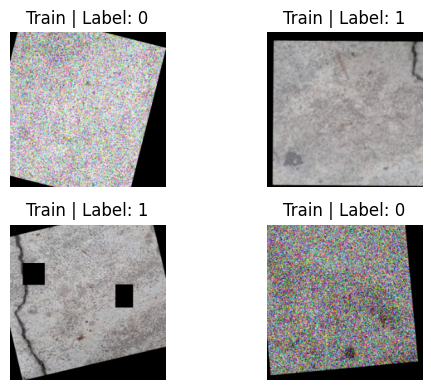


Showing sample images from 'Val'


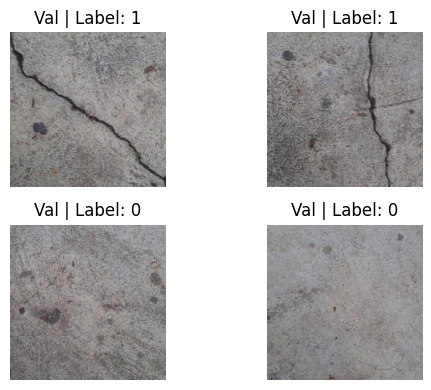


Showing sample images from 'Test'


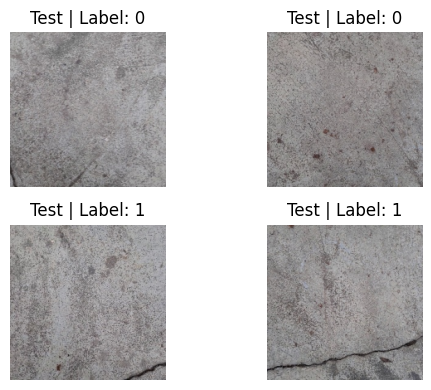

In [16]:
show_samples(train_generator, "Train")
show_samples(val_generator, "Val")
show_samples(test_generator, "Test")

In [17]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['label']),
    y=train_df['label']
)
class_weight_dict = dict(enumerate(class_weights))

In [18]:
train_files = set(train_df['filename'])
val_files = set(val_df['filename'])
test_files = set(test_df['filename'])
print("Overlap train-val:", len(train_files & val_files))
print("Overlap train-test:", len(train_files & test_files))
print("Overlap val-test:", len(val_files & test_files))

Overlap train-val: 0
Overlap train-test: 0
Overlap val-test: 0


In [19]:
print("Train:", train_df['label'].value_counts(normalize=True))
print("Val:", val_df['label'].value_counts(normalize=True))
print("Test:", test_df['label'].value_counts(normalize=True))

Train: label
0    0.579333
1    0.420667
Name: proportion, dtype: float64
Val: label
0    0.57754
1    0.42246
Name: proportion, dtype: float64
Test: label
0    0.579787
1    0.420213
Name: proportion, dtype: float64


In [20]:
mixed_precision.set_global_policy('mixed_float16')
# Backbone
base_model = EfficientNetB0(include_top=False, 
                            weights='imagenet', 
                            input_shape=(*IMG_SIZE, 3))
base_model.trainable = False  # Freeze in stage 1
# Head
inputs = Input(shape=(*IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(256)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(0.5)(x)
x = Dense(128)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(0.4)(x)
x = Dense(64)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(1, activation='sigmoid', dtype='float32')(x)
model = Model(inputs, outputs)
# Compile with Adam optimizer
optimizer = Adam(learning_rate=0.0001, clipnorm=1.0)
model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [21]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetb0 (Functional)          │ (None, 7, 7, 1280)          │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ cast_1 (Cast)                        │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,420,516 (16.86 MB)

 Trainable params: 370,049 (1.41 MB)

 Non-trainable params: 4,050,467 (15.45 MB)

In [22]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath='best_model_weights.weights.h5',
        monitor='val_loss',
        mode='min',
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_auc',
        factor=0.5,
        patience=3,
        verbose=1,
        mode='max',
        min_lr=1e-6
    )
]

In [23]:
history1 = model.fit(
    train_generator,
    validation_data=val_generator,
    class_weight=class_weight_dict,
    epochs=25,
    callbacks=callbacks
)

Epoch 1/25
46/47 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step - accuracy: 0.5509 - auc: 0.5281 - loss: 0.8486 - precision: 0.4396 - recall: 0.2886
Epoch 1: val_loss improved from inf to 0.61890, saving model to best_model_weights.weights.h5
47/47 ━━━━━━━━━━━━━━━━━━━━ 66s 705ms/step - accuracy: 0.5527 - auc: 0.5308 - loss: 0.8461 - precision: 0.4432 - recall: 0.2915 - val_accuracy: 0.8610 - val_auc: 0.9232 - val_loss: 0.6189 - val_precision: 0.8118 - val_recall: 0.8734 - learning_rate: 1.0000e-04
Epoch 2/25
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.7274 - auc: 0.7626 - loss: 0.6094 - precision: 0.7118 - recall: 0.5830
Epoch 2: val_loss improved from 0.61890 to 0.51656, saving model to best_model_weights.weights.h5
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 107ms/step - accuracy: 0.7274 - auc: 0.7629 - loss: 0.6090 - precision: 0.7120 - recall: 0.5827 - val_accuracy: 0.9037 - val_auc: 0.9742 - val_loss: 0.5166 - val_precision: 0.8506 - val_recall: 0.9367 - learning_rate: 1.0000e-04
Epoch 3/25
47/47

In [24]:
# Fine-tuning (Stage 2)
base_model.trainable = True
fine_tune_optimizer = Adam(learning_rate=1e-5, clipnorm=1.0)
fine_tune_optimizer = mixed_precision.LossScaleOptimizer(fine_tune_optimizer)
model.compile(
    optimizer=fine_tune_optimizer,
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

In [25]:
history2 = model.fit(
    train_generator,
    validation_data=val_generator,
    initial_epoch=history1.epoch[-1] + 1,
    epochs=history1.epoch[-1] + 25,
    callbacks=callbacks,
    class_weight=class_weight_dict
)

Epoch 26/49
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6535 - auc: 0.7086 - loss: 0.7487 - precision: 0.5884 - recall: 0.6315
Epoch 26: val_loss did not improve from 0.12138
47/47 ━━━━━━━━━━━━━━━━━━━━ 185s 2s/step - accuracy: 0.6536 - auc: 0.7087 - loss: 0.7487 - precision: 0.5883 - recall: 0.6318 - val_accuracy: 0.9519 - val_auc: 0.9945 - val_loss: 0.1355 - val_precision: 0.9070 - val_recall: 0.9873 - learning_rate: 1.0000e-05
Epoch 27/49
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.6845 - auc: 0.7534 - loss: 0.6587 - precision: 0.6180 - recall: 0.6767
Epoch 27: val_loss did not improve from 0.12138
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 164ms/step - accuracy: 0.6851 - auc: 0.7539 - loss: 0.6578 - precision: 0.6185 - recall: 0.6773 - val_accuracy: 0.9198 - val_auc: 0.9931 - val_loss: 0.2072 - val_precision: 0.8478 - val_recall: 0.9873 - learning_rate: 1.0000e-05
Epoch 28/49
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.7401 - auc: 0.8038 - loss: 0.5804 - precision: 

In [26]:
combined_history = {}
for key in history1.history.keys():
    combined_history[key] = history1.history[key] + history2.history[key]

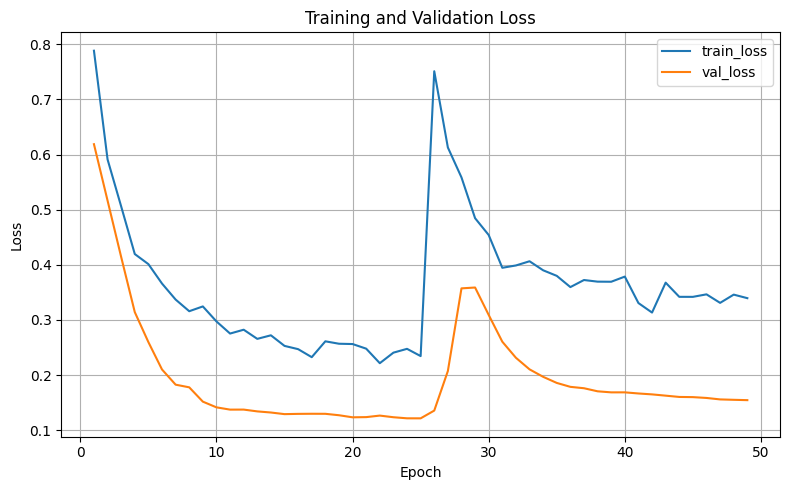

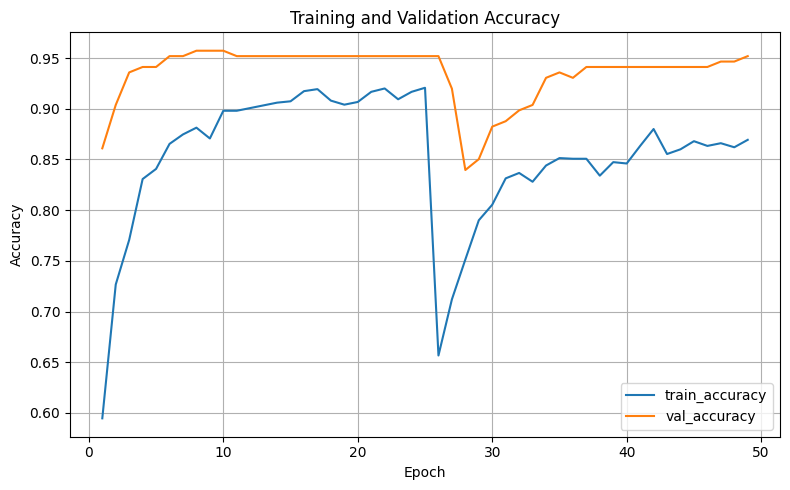

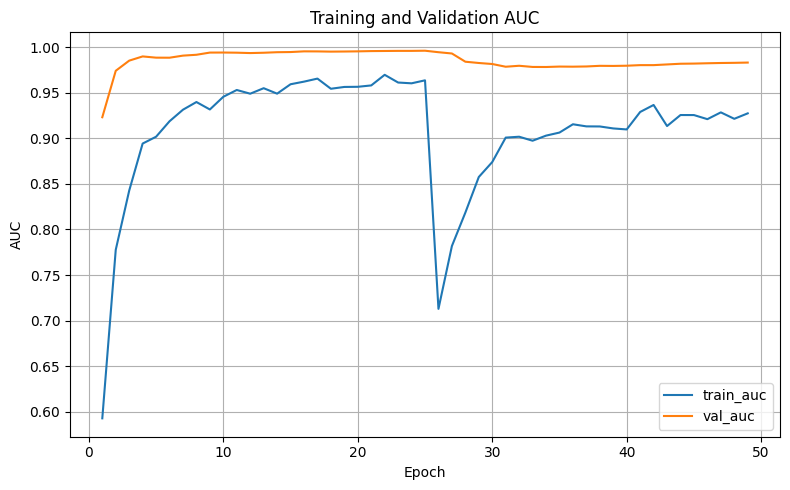

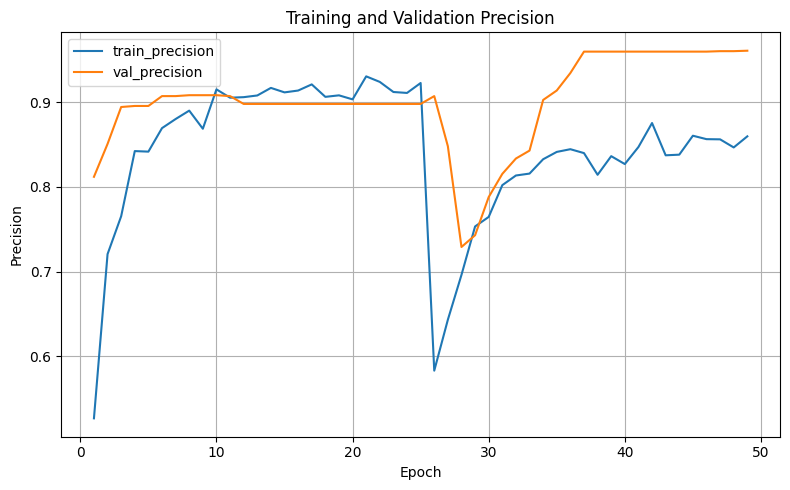

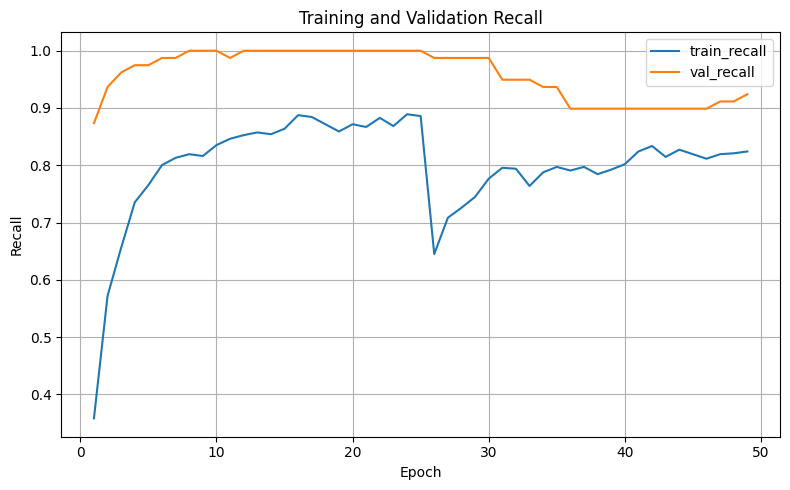

In [27]:
epochs = range(1, len(combined_history['loss']) + 1)
# Plot training & validation loss
plt.figure(figsize=(8, 5))
plt.plot(epochs, combined_history['loss'], label='train_loss')
plt.plot(epochs, combined_history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot Accuracy
plt.figure(figsize=(8, 5))
plt.plot(epochs, combined_history['accuracy'], label='train_accuracy')
plt.plot(epochs, combined_history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot AUC
plt.figure(figsize=(8, 5))
plt.plot(epochs, combined_history['auc'], label='train_auc')
plt.plot(epochs, combined_history['val_auc'], label='val_auc')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.title('Training and Validation AUC')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot Precision
plt.figure(figsize=(8, 5))
plt.plot(epochs, combined_history['precision'], label='train_precision')
plt.plot(epochs, combined_history['val_precision'], label='val_precision')
plt.xlabel('Epoch')
plt.ylabel('Precision')
plt.title('Training and Validation Precision')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot Recall
plt.figure(figsize=(8, 5))
plt.plot(epochs, combined_history['recall'], label='train_recall')
plt.plot(epochs, combined_history['val_recall'], label='val_recall')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.title('Training and Validation Recall')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [28]:
# Evaluate model on test
test_loss, test_acc, test_auc, test_precision, test_recall = model.evaluate(test_generator, verbose=1)
print(f"Test Accuracy:  {test_acc:.4f}")
print(f"Test AUC:       {test_auc:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall:    {test_recall:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 775ms/step - accuracy: 0.9213 - auc: 0.9584 - loss: 0.2294 - precision: 0.9480 - recall: 0.8535
Test Accuracy:  0.9362
Test AUC:       0.9728
Test Precision: 0.9718
Test Recall:    0.8734


In [29]:
model.load_weights('/kaggle/working/best_model_weights.weights.h5')
# Predict on test set
y_pred_probs = model.predict(test_generator, verbose=1)
# Convert probabilities to binary predictions (threshold = 0.5)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()
# True labels from generator
y_true = test_generator.dataframe['label'].astype(int).values[:len(y_pred)]  # align length just in case
# Evaluation
from sklearn.metrics import classification_report, f1_score
f1 = f1_score(y_true, y_pred)
print(f"\nF1-score: {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["no crack", "crack"]))

/usr/local/lib/python3.10/dist-packages/keras/src/saving/saving_lib.py:713: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 456 variables whereas the saved optimizer has 34 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.10/dist-packages/keras/src/saving/saving_lib.py:713: UserWarning: Skipping variable loading for optimizer 'adam', because it has 452 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step

F1-score: 0.9231

Classification Report:
              precision    recall  f1-score   support

    no crack       0.99      0.89      0.94       109
       crack       0.87      0.99      0.92        79

    accuracy                           0.93       188
   macro avg       0.93      0.94      0.93       188
weighted avg       0.94      0.93      0.93       188

